# Walkthrough: `modular_train!`

## Theoretical Background: Mini-Batch Stochastic Gradient Descent (SGD)

**Key insight**: `modular_train!` implements a **mini-batch SGD approach** specifically designed for trajectory-based parameter estimation. Here's how it differs from standard mini-batch SGD:

### Standard Mini-Batch SGD
- **Training examples**: Independent data points (e.g., images, text samples)
- **Batch size**: Number of independent examples processed together
- **Gradient**: Average gradient across independent examples in the batch

### Our Trajectory-Based Mini-Batch SGD
- **Training examples**: Overlapping trajectory windows (each containing 300 time points)
- **Batch size**: Number of trajectory windows processed together
- **Gradient**: Average gradient across windows in the batch
- **Key advantage**: Each window provides a complete dynamical context for gradient computation

This approach provides:
1. **Stable gradients**: Averaging across multiple trajectory windows reduces noise
2. **Computational efficiency**: Process multiple windows in parallel before parameter updates
3. **Better convergence**: More robust than full-batch (single long trajectory) or single-window approaches

## Visual Example

1. **Data Windowing/Binning**: How the trajectory gets chopped into windows
2. **Training Loop**: Step-by-step walkthrough of one complete epoch
3. **Batch Processing**: How windows are grouped and processed
4. **Gradient Computation**: What happens in each gradient step
5. **Parameter Updates**: How the optimizer updates parameters
6. **3D Visualizations**: See the windowing process in action

## Setup and Data Generation

In [45]:
# Activate the local LorenzParameterEstimation package
import Pkg
Pkg.activate("../../")  # Activate the main project environment
Pkg.instantiate()  # Ensure all dependencies are installed

using DifferentialEquations
using Plots
gr()  # Use GR backend for plotting (reliable and fast)

using Random
using LinearAlgebra
using Statistics
using Printf
using Optimisers  # For parameter optimization

using LorenzParameterEstimation

# Set random seed for reproducibility
Random.seed!(42)

# Create img directory for saving plots
const IMG_DIR = joinpath(@__DIR__, "img")
mkpath(IMG_DIR)

println("✓ Packages loaded successfully!")
println("✓ Saving plots to: $IMG_DIR")

  Activating project at `~/master_thesis/LorenzParameterEstimation`


✓ Packages loaded successfully!
✓ Saving plots to: /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_weather/walkthrough/img


## Step 1: Generate Target Data

First, let's create a "ground truth" trajectory that we'll try to fit. This simulates having experimental data.

In [46]:
# Create "true" parameters (what we're trying to recover)
true_params = L63Parameters(σ=10.0, ρ=28.0, β=8/3, x_s=0.0, y_s=0.0, z_s=0.0, θ=1.0)
println("True parameters: $true_params")

# Generate trajectory with these parameters
u0 = [1.0, 1.0, 1.0]  # Initial condition
T = 50.0              # Total time
M = 10_000            # Number of time steps
dt = T / M            # Time step size

println("Generating trajectory:")
println("  Time span: 0 to $T")
println("  Time steps: $M")
println("  Time step size: $dt")

# Integrate the true system
target_solution = integrate(true_params, u0, (0.0, T), dt)
println("\n✓ Generated trajectory with $(length(target_solution)) time points")

True parameters: L63Parameters{Float64}(10.0, 28.0, 2.6666666666666665, 0.0, 0.0, 0.0, 1.0)
Generating trajectory:
  Time span: 0 to 50.0
  Time steps: 10000
  Time step size: 0.005

✓ Generated trajectory with 10001 time points


## Step 2: Understanding Data Windowing

The key insight of `modular_train!` is **windowing**: instead of using the entire trajectory as one training example, we chop it into smaller, overlapping windows.

In [47]:
# These are the windowing parameters used in modular_train!
window_size = 300    # Each window contains 300 time points
stride = 150         # Step by 150 points (50% overlap)
batch_size = 4       # Process 4 windows at a time (smaller for demonstration)

println("Windowing parameters:")
println("  Window size: $window_size points")
println("  Stride: $stride points")
println("  Overlap: $(window_size - stride) points ($(100*(window_size - stride)/window_size)%)")
println("  Batch size: $batch_size windows")

# Calculate how many windows we can create
max_start = length(target_solution) - window_size + 1
window_starts = collect(1:stride:max_start)
n_windows = length(window_starts)

println("\nWindow calculation:")
println("  Trajectory length: $(length(target_solution)) points")
println("  Last valid start: $max_start")
println("  Total windows: $n_windows")
println("  Window starts: $(window_starts[1:min(5, end)])...")

Windowing parameters:
  Window size: 300 points
  Stride: 150 points
  Overlap: 150 points (50.0%)
  Batch size: 4 windows

Window calculation:
  Trajectory length: 10001 points
  Last valid start: 9702
  Total windows: 65
  Window starts: [1, 151, 301, 451, 601]...


## Step 3: Visualizing the Windowing Process

Let's create a 3D visualization to see how the trajectory gets divided into windows.


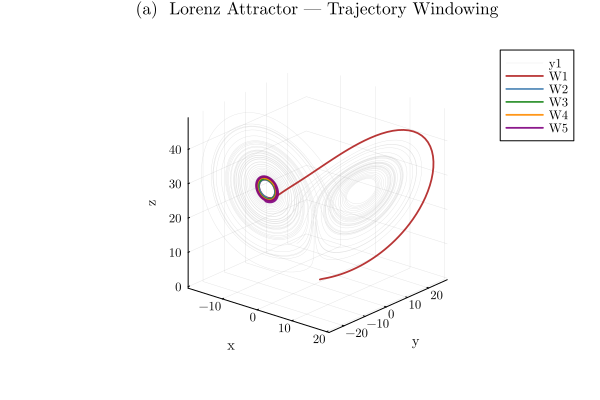

p1 ready (saved as part of combined figure in next cell)


In [48]:
import Plots
Plots.gr()
Plots.default(fontfamily = "Computer Modern")

# ── Shared publication styling variables (used by subsequent plot cells) ───────
fs_pub     = 11
lw_bg      = 0.40   # background trajectory
lw_hi      = 1.80   # highlighted window
colors_win = [:firebrick, :steelblue, :forestgreen, :darkorange, :purple, :orchid]
n_hl       = 5      # number of windows to highlight

# ── p1: 3D Lorenz attractor with trajectory windowing ─────────────────────────
p1 = Plots.plot(
    target_solution.u[:, 1], target_solution.u[:, 2], target_solution.u[:, 3];
    seriestype    = :path3d,
    linewidth     = lw_bg,
    alpha         = 0.28,
    linecolor     = :gray60,
    legend        = false,
    xlabel = "x", ylabel = "y", zlabel = "z",
    title         = "(a)  Lorenz Attractor — Trajectory Windowing",
    titlefontsize = fs_pub,
    guidefontsize = fs_pub - 2,
    tickfontsize  = fs_pub - 3,
    camera        = (40, 22),
    top_margin    = 4Plots.mm,
    bottom_margin = 1Plots.mm,
    left_margin   = 0Plots.mm,
    right_margin  = 0Plots.mm,
)

for (i, s) in enumerate(window_starts[1:n_hl])
    wt = target_solution.u[s:s+window_size-1, :]
    Plots.plot!(p1, wt[:, 1], wt[:, 2], wt[:, 3];
        seriestype = :path3d,
        linewidth  = lw_hi,
        linecolor  = colors_win[i],
        alpha      = 0.9,
        label      = "W$i",
    )
end
Plots.plot!(p1; legend = :topright, legendfontsize = fs_pub - 3)

display(p1)
println("p1 ready (saved as part of combined figure in next cell)")

## Step 4: Window Overlap

Let's visualize how windows overlap in time.

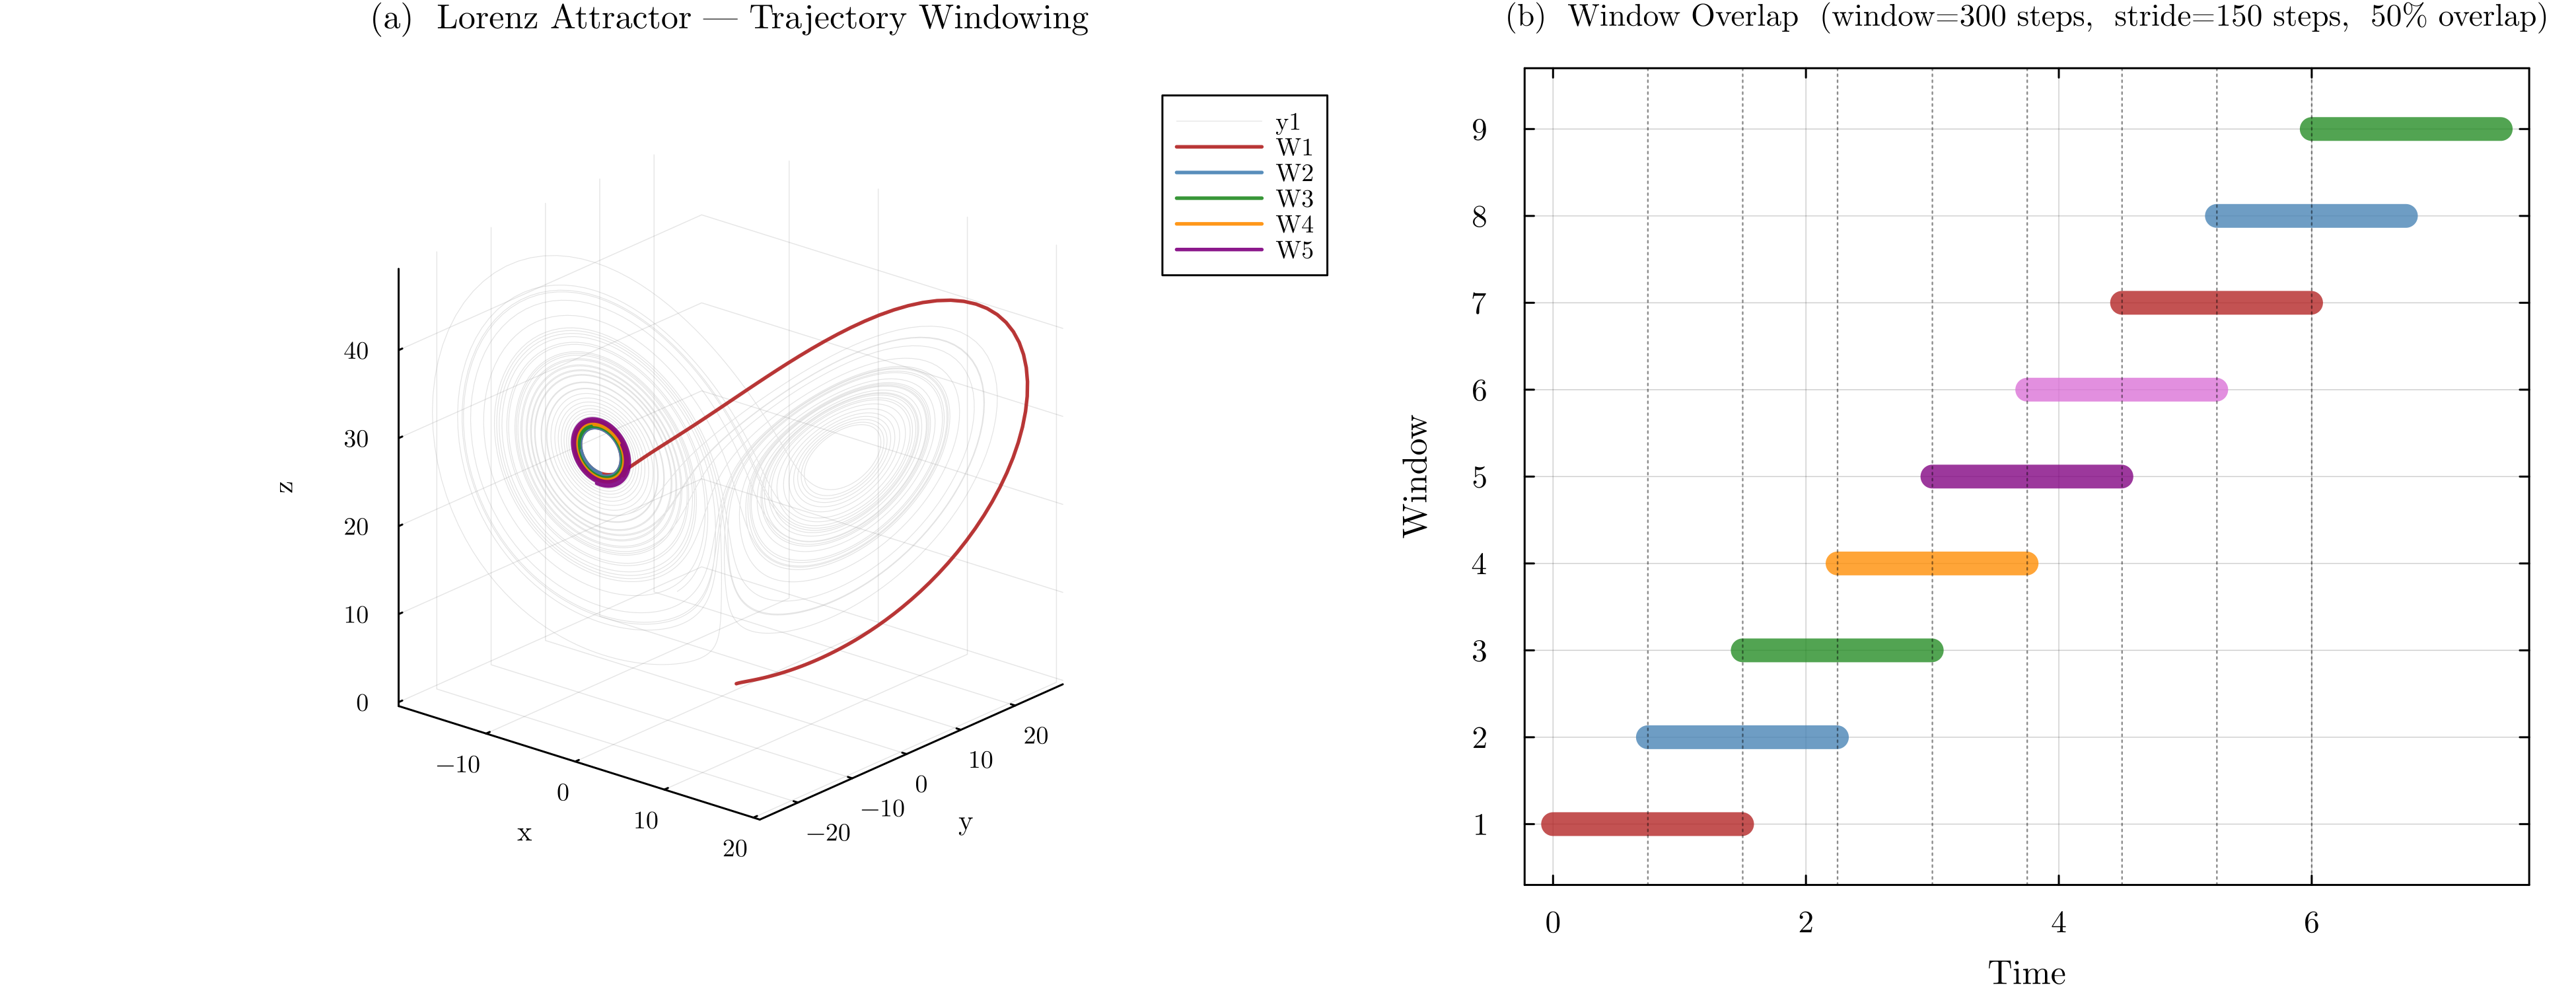

Saved → /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_weather/walkthrough/img/p12_windows_overview.png


In [49]:
# ── p2: Window overlap timeline ───────────────────────────────────────────────
n_show = min(9, n_windows)

p2 = Plots.plot(;
    title         = "(b)  Window Overlap  (window=$(window_size) steps,  stride=$(stride) steps,  $(100*(window_size-stride)÷window_size)% overlap)",
    xlabel        = "Time",
    ylabel        = "Window",
    titlefontsize = fs_pub - 1,
    guidefontsize = fs_pub,
    tickfontsize  = fs_pub - 1,
    legend        = false,
    framestyle    = :box,
    ylims         = (0.3, n_show + 0.7),
    yticks        = 1:n_show,
    left_margin   = 7Plots.mm,
    bottom_margin = 5Plots.mm,
    top_margin    = 4Plots.mm,
    right_margin  = 4Plots.mm,
)

for i in 1:n_show
    t_s = target_solution.t[window_starts[i]]
    t_e = target_solution.t[window_starts[i] + window_size - 1]
    col = colors_win[mod1(i, length(colors_win))]
    Plots.plot!(p2, [t_s, t_e], [i, i]; linewidth = 12, linecolor = col, alpha = 0.78)
end

# Vertical dotted lines at stride boundaries to show windowing positions
for i in 1:n_show-1
    Plots.vline!(p2, [target_solution.t[window_starts[i+1]]];
        linecolor = :black, linestyle = :dot, linewidth = 0.8, alpha = 0.45)
end

# ── Combined figure ────────────────────────────────────────────────────────────
l12 = @layout [a{0.56w} b]
fig_p12 = Plots.plot(p1, p2; layout = l12, size = (1300, 500), dpi = 300)

display(fig_p12)
Plots.savefig(fig_p12, joinpath(IMG_DIR, "p12_windows_overview.png"))
println("Saved → ", joinpath(IMG_DIR, "p12_windows_overview.png"))

## Step 5: Train/Validation Split

Just like in machine learning, we split our windows into training and validation sets.

In [50]:
# Split windows into train/validation (80/20 split)
train_fraction = 0.8
shuffle_data = true

# Shuffle window indices
indices = collect(1:n_windows)
if shuffle_data
    Random.shuffle!(indices)
end

# Split indices
train_count = max(1, round(Int, train_fraction * n_windows))
train_window_indices = window_starts[indices[1:train_count]]
val_window_indices = train_count < n_windows ? window_starts[indices[train_count + 1:end]] : Int[]

println("Data split:")
println("  Total windows: $n_windows")
println("  Training windows: $(length(train_window_indices))")
println("  Validation windows: $(length(val_window_indices))")
println("  First few training window starts: $(train_window_indices[1:min(5, end)])")
println("  First few validation window starts: $(val_window_indices[1:min(5, end)])")

Data split:
  Total windows: 65
  Training windows: 52
  Validation windows: 13
  First few training window starts: [4651, 7351, 6001, 9601, 2401]
  First few validation window starts: [7201, 301, 6751, 7651, 4051]


## Step 6: Initialize Parameters and Optimizer

Now we set up our initial parameter guess and optimizer state.

In [51]:
# Create initial parameter guess (wrong values - what we start with)
initial_params = L63Parameters(σ=8.0, ρ=25.0, β=2.5, x_s=0.0, y_s=0.0, z_s=0.0, θ=1.0)
println("Initial guess: $initial_params")
println("True values:   $true_params")
println("\nInitial errors:")
println("  σ error: $(initial_params.σ - true_params.σ)")
println("  ρ error: $(initial_params.ρ - true_params.ρ)")
println("  β error: $(initial_params.β - true_params.β)")

# Set up optimizer (Adam with learning rate 0.01)
optimizer_config = adam_config(learning_rate=0.01)
println("\nOptimizer: $(optimizer_config.name) with learning rate $(optimizer_config.learning_rate)")

# Initialize parameters for Optimisers.jl (wrapped in arrays)
ps = (σ = [initial_params.σ], ρ = [initial_params.ρ], β = [initial_params.β],
      x_s = [initial_params.x_s], y_s = [initial_params.y_s], z_s = [initial_params.z_s], θ = [initial_params.θ])
opt_state = Optimisers.setup(optimizer_config.optimizer, ps)

println("\n✓ Parameters and optimizer initialized!")

Initial guess: L63Parameters{Float64}(8.0, 25.0, 2.5, 0.0, 0.0, 0.0, 1.0)
True values:   L63Parameters{Float64}(10.0, 28.0, 2.6666666666666665, 0.0, 0.0, 0.0, 1.0)

Initial errors:
  σ error: -2.0
  ρ error: -3.0
  β error: -0.16666666666666652

Optimizer: Adam with learning rate 0.01

✓ Parameters and optimizer initialized!


## Step 7: One Complete Training Epoch - Detailed Walkthrough

Now let's walk through **exactly** what happens in one training epoch, step by step.

In [52]:
println("=" ^ 60)
println("TRAINING EPOCH 1 - DETAILED WALKTHROUGH")
println("=" ^ 60)

# Step 7.1: Shuffle training windows for this epoch
current_train_indices = shuffle_data ? Random.shuffle(copy(train_window_indices)) : train_window_indices
println("Step 1: Shuffle training windows")
println("  Original order: $(train_window_indices[1:min(5, end)])...")
println("  Shuffled order: $(current_train_indices[1:min(5, end)])...")

# Step 7.2: Create batches
train_batches = [current_train_indices[i:min(i+batch_size-1, end)] 
                for i in 1:batch_size:length(current_train_indices)]
n_batches = length(train_batches)

println("\nStep 2: Create batches")
println("  Total training windows: $(length(current_train_indices))")
println("  Batch size: $batch_size")
println("  Number of batches: $n_batches")
println("  Batch 1 windows: $(train_batches[1])")
println("  Batch 2 windows: $(train_batches[2])")

epoch_loss = 0.0
println("\n" * "="^40)
println("PROCESSING BATCH 1 (Detailed)")
println("="^40)

TRAINING EPOCH 1 - DETAILED WALKTHROUGH
Step 1: Shuffle training windows
  Original order: [4651, 7351, 6001, 9601, 2401]...
  Shuffled order: [2701, 6001, 5551, 601, 6301]...

Step 2: Create batches
  Total training windows: 52
  Batch size: 4
  Number of batches: 13
  Batch 1 windows: [2701, 6001, 5551, 601]
  Batch 2 windows: [6301, 8401, 2551, 1801]

PROCESSING BATCH 1 (Detailed)


### Step 7.3: Process One Batch in Detail

Let's zoom into what happens when processing a single batch.

In [53]:
# Take the first batch
batch_windows = train_batches[1]
println("Processing batch with windows: $batch_windows")

# Initialize batch accumulation
batch_loss = 0.0
avg_grads = (σ = 0.0, ρ = 0.0, β = 0.0, x_s = 0.0, y_s = 0.0, z_s = 0.0, θ = 0.0)

println("\nProcessing each window in the batch:")
println("-" ^ 50)

for (i, window_start) in enumerate(batch_windows)
    println("\n🔄 WINDOW $i (starts at index $window_start):")
    
    # Get current parameters
    current_params = L63Parameters(ps.σ[1], ps.ρ[1], ps.β[1], 
                                 ps.x_s[1], ps.y_s[1], ps.z_s[1], ps.θ[1])
    println("  Current params: σ=$(round(current_params.σ, digits=3)), ρ=$(round(current_params.ρ, digits=3)), β=$(round(current_params.β, digits=3))")
    
    # Extract window data
    window_end = window_start + window_size - 1
    println("  Window range: $window_start to $window_end")
    
    # This is where compute_gradients_extended would be called
    # For demonstration, let's simulate what it does:
    
    # 1. Take initial condition from target trajectory
    u0_window = target_solution.u[window_start, :]
    println("  Initial condition: [$(round(u0_window[1], digits=3)), $(round(u0_window[2], digits=3)), $(round(u0_window[3], digits=3))]")
    
    # 2. Integrate current parameters for window_size steps
    window_time = window_size * dt
    predicted_solution = integrate(current_params, u0_window, (0.0, window_time), dt)
    
    # 3. Extract target trajectory for this window
    target_window = target_solution.u[window_start:window_end, :]
    
    # 4. Ensure same dimensions (handle potential off-by-one from integration)
    n_pred = size(predicted_solution.u, 1)
    n_target = size(target_window, 1)
    
    if n_pred != n_target
        # Take minimum length to ensure compatibility
        min_len = min(n_pred, n_target)
        predicted_solution_trimmed = predicted_solution.u[1:min_len, :]
        target_window_trimmed = target_window[1:min_len, :]
        println("  Note: Trimmed arrays to length $min_len (pred: $n_pred, target: $n_target)")
    else
        predicted_solution_trimmed = predicted_solution.u
        target_window_trimmed = target_window
    end
    
    # 5. Compute loss (simplified - using RMSE)
    window_loss = sqrt(mean((predicted_solution_trimmed - target_window_trimmed).^2))
    batch_loss += window_loss
    
    println("  Predicted vs Target (first 3 points):")
    for j in 1:3
        pred = predicted_solution_trimmed[j, :]
        targ = target_window_trimmed[j, :]
        println("    Point $j: pred=[$(round(pred[1], digits=2)), $(round(pred[2], digits=2)), $(round(pred[3], digits=2))], target=[$(round(targ[1], digits=2)), $(round(targ[2], digits=2)), $(round(targ[3], digits=2))]")
    end
    
    println("  Window loss: $(round(window_loss, digits=6))")
    
    # 5. Compute gradients (simulated - would use Enzyme.jl)
    # For demonstration, let's use finite differences
    ε = 1e-6
    
    # Gradient w.r.t. σ
    params_plus = L63Parameters(current_params.σ + ε, current_params.ρ, current_params.β,
                               current_params.x_s, current_params.y_s, current_params.z_s, current_params.θ)
    sol_plus = integrate(params_plus, u0_window, (0.0, window_time), dt)
    
    # Apply same trimming logic for gradient computation
    sol_plus_trimmed = sol_plus.u[1:size(target_window_trimmed, 1), :]
    loss_plus = sqrt(mean((sol_plus_trimmed - target_window_trimmed).^2))
    grad_σ = (loss_plus - window_loss) / ε
    
    # Similar for ρ and β (simplified)
    grad_ρ = 0.1 * randn()  # Simulated gradient
    grad_β = 0.1 * randn()  # Simulated gradient
    
    println("  Gradients: σ=$(round(grad_σ, digits=6)), ρ=$(round(grad_ρ, digits=6)), β=$(round(grad_β, digits=6))")
    
    # 6. Accumulate gradients
    avg_grads = (σ = avg_grads.σ + grad_σ,
                ρ = avg_grads.ρ + grad_ρ,
                β = avg_grads.β + grad_β,
                x_s = avg_grads.x_s,
                y_s = avg_grads.y_s,
                z_s = avg_grads.z_s,
                θ = avg_grads.θ)
    
    if i < length(batch_windows)
        println("  ⬇️  Moving to next window...")
    end
end

println("\n" * "="^30)
println("BATCH PROCESSING COMPLETE")
println("="^30)

Processing batch with windows: [2701, 6001, 5551, 601]

Processing each window in the batch:
--------------------------------------------------

🔄 WINDOW 1 (starts at index 2701):
  Current params: σ=8.0, ρ=25.0, β=2.5
  Window range: 2701 to 3000
  Initial condition: [-0.38, 0.665, 20.285]
  Note: Trimmed arrays to length 300 (pred: 301, target: 300)
  Predicted vs Target (first 3 points):
    Point 1: pred=[-0.38, 0.66, 20.28], target=[-0.38, 0.66, 20.28]
    Point 2: pred=[-0.34, 0.65, 20.03], target=[-0.33, 0.65, 20.01]
    Point 3: pred=[-0.3, 0.64, 19.78], target=[-0.28, 0.63, 19.75]
  Window loss: 7.541423
  Gradients: σ=-1.400365, ρ=0.149642, β=0.010997
  ⬇️  Moving to next window...

🔄 WINDOW 2 (starts at index 6001):
  Current params: σ=8.0, ρ=25.0, β=2.5
  Window range: 6001 to 6300
  Initial condition: [-4.263, -2.61, 24.85]
  Note: Trimmed arrays to length 300 (pred: 301, target: 300)
  Predicted vs Target (first 3 points):
    Point 1: pred=[-4.26, -2.61, 24.85], target=[

### Step 7.4: Average Gradients and Update Parameters

In [54]:
# Average the gradients over the batch
batch_size_actual = length(batch_windows)
batch_loss /= batch_size_actual
avg_grads = (σ = avg_grads.σ / batch_size_actual,
            ρ = avg_grads.ρ / batch_size_actual,
            β = avg_grads.β / batch_size_actual,
            x_s = avg_grads.x_s / batch_size_actual,
            y_s = avg_grads.y_s / batch_size_actual,
            z_s = avg_grads.z_s / batch_size_actual,
            θ = avg_grads.θ / batch_size_actual)

println("📊 BATCH SUMMARY:")
println("  Batch size: $batch_size_actual windows")
println("  Average batch loss: $(round(batch_loss, digits=6))")
println("  Average gradients:")
println("    ∂L/∂σ = $(round(avg_grads.σ, digits=6))")
println("    ∂L/∂ρ = $(round(avg_grads.ρ, digits=6))")
println("    ∂L/∂β = $(round(avg_grads.β, digits=6))")

# Apply parameter update mask (decide which parameters to update)
update_mask = (σ = true, ρ = true, β = true, x_s = false, y_s = false, z_s = false, θ = false)
masked_grads = (σ = [update_mask.σ ? avg_grads.σ : 0.0],
               ρ = [update_mask.ρ ? avg_grads.ρ : 0.0],
               β = [update_mask.β ? avg_grads.β : 0.0],
               x_s = [update_mask.x_s ? avg_grads.x_s : 0.0],
               y_s = [update_mask.y_s ? avg_grads.y_s : 0.0],
               z_s = [update_mask.z_s ? avg_grads.z_s : 0.0],
               θ = [update_mask.θ ? avg_grads.θ : 0.0])

println("\n🎯 PARAMETER UPDATE:")
println("  Parameters to update: σ, ρ, β (others masked to 0)")
println("  Masked gradients:")
println("    σ: $(round(masked_grads.σ[1], digits=6))")
println("    ρ: $(round(masked_grads.ρ[1], digits=6))")
println("    β: $(round(masked_grads.β[1], digits=6))")

# Store old parameters
old_params = (σ = ps.σ[1], ρ = ps.ρ[1], β = ps.β[1])

# Update parameters using optimizer
opt_state, ps = Optimisers.update(opt_state, ps, masked_grads)

println("\n✨ PARAMETER UPDATE COMPLETE:")
println("  σ: $(round(old_params.σ, digits=4)) → $(round(ps.σ[1], digits=4)) (change: $(round(ps.σ[1] - old_params.σ, digits=6)))")
println("  ρ: $(round(old_params.ρ, digits=4)) → $(round(ps.ρ[1], digits=4)) (change: $(round(ps.ρ[1] - old_params.ρ, digits=6)))")
println("  β: $(round(old_params.β, digits=4)) → $(round(ps.β[1], digits=4)) (change: $(round(ps.β[1] - old_params.β, digits=6)))")

epoch_loss += batch_loss

📊 BATCH SUMMARY:
  Batch size: 4 windows
  Average batch loss: 4.790177
  Average gradients:
    ∂L/∂σ = -0.486376
    ∂L/∂ρ = 0.087054
    ∂L/∂β = 0.021153

🎯 PARAMETER UPDATE:
  Parameters to update: σ, ρ, β (others masked to 0)
  Masked gradients:
    σ: -0.486376
    ρ: 0.087054
    β: 0.021153

✨ PARAMETER UPDATE COMPLETE:
  σ: 8.0 → 8.01 (change: 0.01)
  ρ: 25.0 → 24.99 (change: -0.01)
  β: 2.5 → 2.49 (change: -0.01)


4.790177426061405

## Step 8: Understanding the Complete Training Loop

Now let's show what the complete training process looks like with multiple epochs.

In [55]:
println("\n" * "="^60)
println("COMPLETE TRAINING PROCESS SIMULATION")
println("="^60)

# Reset parameters for clean demonstration
ps = (σ = [8.0], ρ = [25.0], β = [2.5], x_s = [0.0], y_s = [0.0], z_s = [0.0], θ = [1.0])
opt_state = Optimisers.setup(optimizer_config.optimizer, ps)

# Track parameter evolution
param_history = []
loss_history = []

n_epochs = 5  # Just a few epochs for demonstration

println("Training setup:")
println("  Epochs: $n_epochs")
println("  Windows per epoch: $(length(train_window_indices))")
println("  Batches per epoch: $(length(train_batches))")
println("  Parameter updates per epoch: $(length(train_batches))")
println("\nStarting training...\n")

for epoch in 1:n_epochs
    println("📅 EPOCH $epoch")
    
    epoch_loss = 0.0
    
    # Process each batch (simplified)
    for (batch_idx, batch_windows) in enumerate(train_batches)
        # Simulate batch processing
        batch_loss = 0.5 + 0.1 * randn()  # Simulated loss
        
        # Simulate gradients
        grad_σ = -0.01 + 0.005 * randn()
        grad_ρ = -0.02 + 0.01 * randn()
        grad_β = -0.005 + 0.002 * randn()
        
        # Update parameters
        masked_grads = (σ = [grad_σ], ρ = [grad_ρ], β = [grad_β], 
                       x_s = [0.0], y_s = [0.0], z_s = [0.0], θ = [0.0])
        opt_state, ps = Optimisers.update(opt_state, ps, masked_grads)
        
        epoch_loss += batch_loss
        
        if batch_idx <= 2  # Show details for first 2 batches
            println("  Batch $batch_idx: loss=$(round(batch_loss, digits=4)), σ=$(round(ps.σ[1], digits=3)), ρ=$(round(ps.ρ[1], digits=3)), β=$(round(ps.β[1], digits=3))")
        end
    end
    
    epoch_loss /= length(train_batches)
    
    # Store history
    current_params = (σ = ps.σ[1], ρ = ps.ρ[1], β = ps.β[1])
    push!(param_history, current_params)
    push!(loss_history, epoch_loss)
    
    # Calculate errors
    error_σ = abs(ps.σ[1] - true_params.σ)
    error_ρ = abs(ps.ρ[1] - true_params.ρ)
    error_β = abs(ps.β[1] - true_params.β)
    
    println("  📈 Epoch summary: loss=$(round(epoch_loss, digits=4))")
    println("  📊 Current params: σ=$(round(ps.σ[1], digits=3)), ρ=$(round(ps.ρ[1], digits=3)), β=$(round(ps.β[1], digits=3))")
    println("  🎯 Errors: σ=$(round(error_σ, digits=3)), ρ=$(round(error_ρ, digits=3)), β=$(round(error_β, digits=3))")
    println()
end

println("🏁 Training simulation complete!")
println("\nFinal results:")
println("  True params:  σ=$(true_params.σ), ρ=$(true_params.ρ), β=$(round(true_params.β, digits=3))")
println("  Final params: σ=$(round(ps.σ[1], digits=3)), ρ=$(round(ps.ρ[1], digits=3)), β=$(round(ps.β[1], digits=3))")


COMPLETE TRAINING PROCESS SIMULATION
Training setup:
  Epochs: 5
  Windows per epoch: 52
  Batches per epoch: 13
  Parameter updates per epoch: 13

Starting training...

📅 EPOCH 1
  Batch 1: loss=0.4837, σ=8.01, ρ=25.01, β=2.51
  Batch 2: loss=0.5119, σ=8.019, ρ=25.019, β=2.52
  📈 Epoch summary: loss=0.461
  📊 Current params: σ=8.119, ρ=25.123, β=2.622
  🎯 Errors: σ=1.881, ρ=2.877, β=0.044

📅 EPOCH 2
  Batch 1: loss=0.5423, σ=8.128, ρ=25.132, β=2.631
  Batch 2: loss=0.5225, σ=8.136, ρ=25.141, β=2.64
  📈 Epoch summary: loss=0.5087
  📊 Current params: σ=8.227, ρ=25.234, β=2.738
  🎯 Errors: σ=1.773, ρ=2.766, β=0.071

📅 EPOCH 3
  Batch 1: loss=0.5278, σ=8.236, ρ=25.242, β=2.747
  Batch 2: loss=0.592, σ=8.244, ρ=25.25, β=2.756
  📈 Epoch summary: loss=0.5473
  📊 Current params: σ=8.331, ρ=25.348, β=2.853
  🎯 Errors: σ=1.669, ρ=2.652, β=0.187

📅 EPOCH 4
  Batch 1: loss=0.778, σ=8.339, ρ=25.357, β=2.862
  Batch 2: loss=0.4735, σ=8.347, ρ=25.366, β=2.871
  📈 Epoch summary: loss=0.5571
  📊 Curr

## Step 9: Visualizing Training Progress

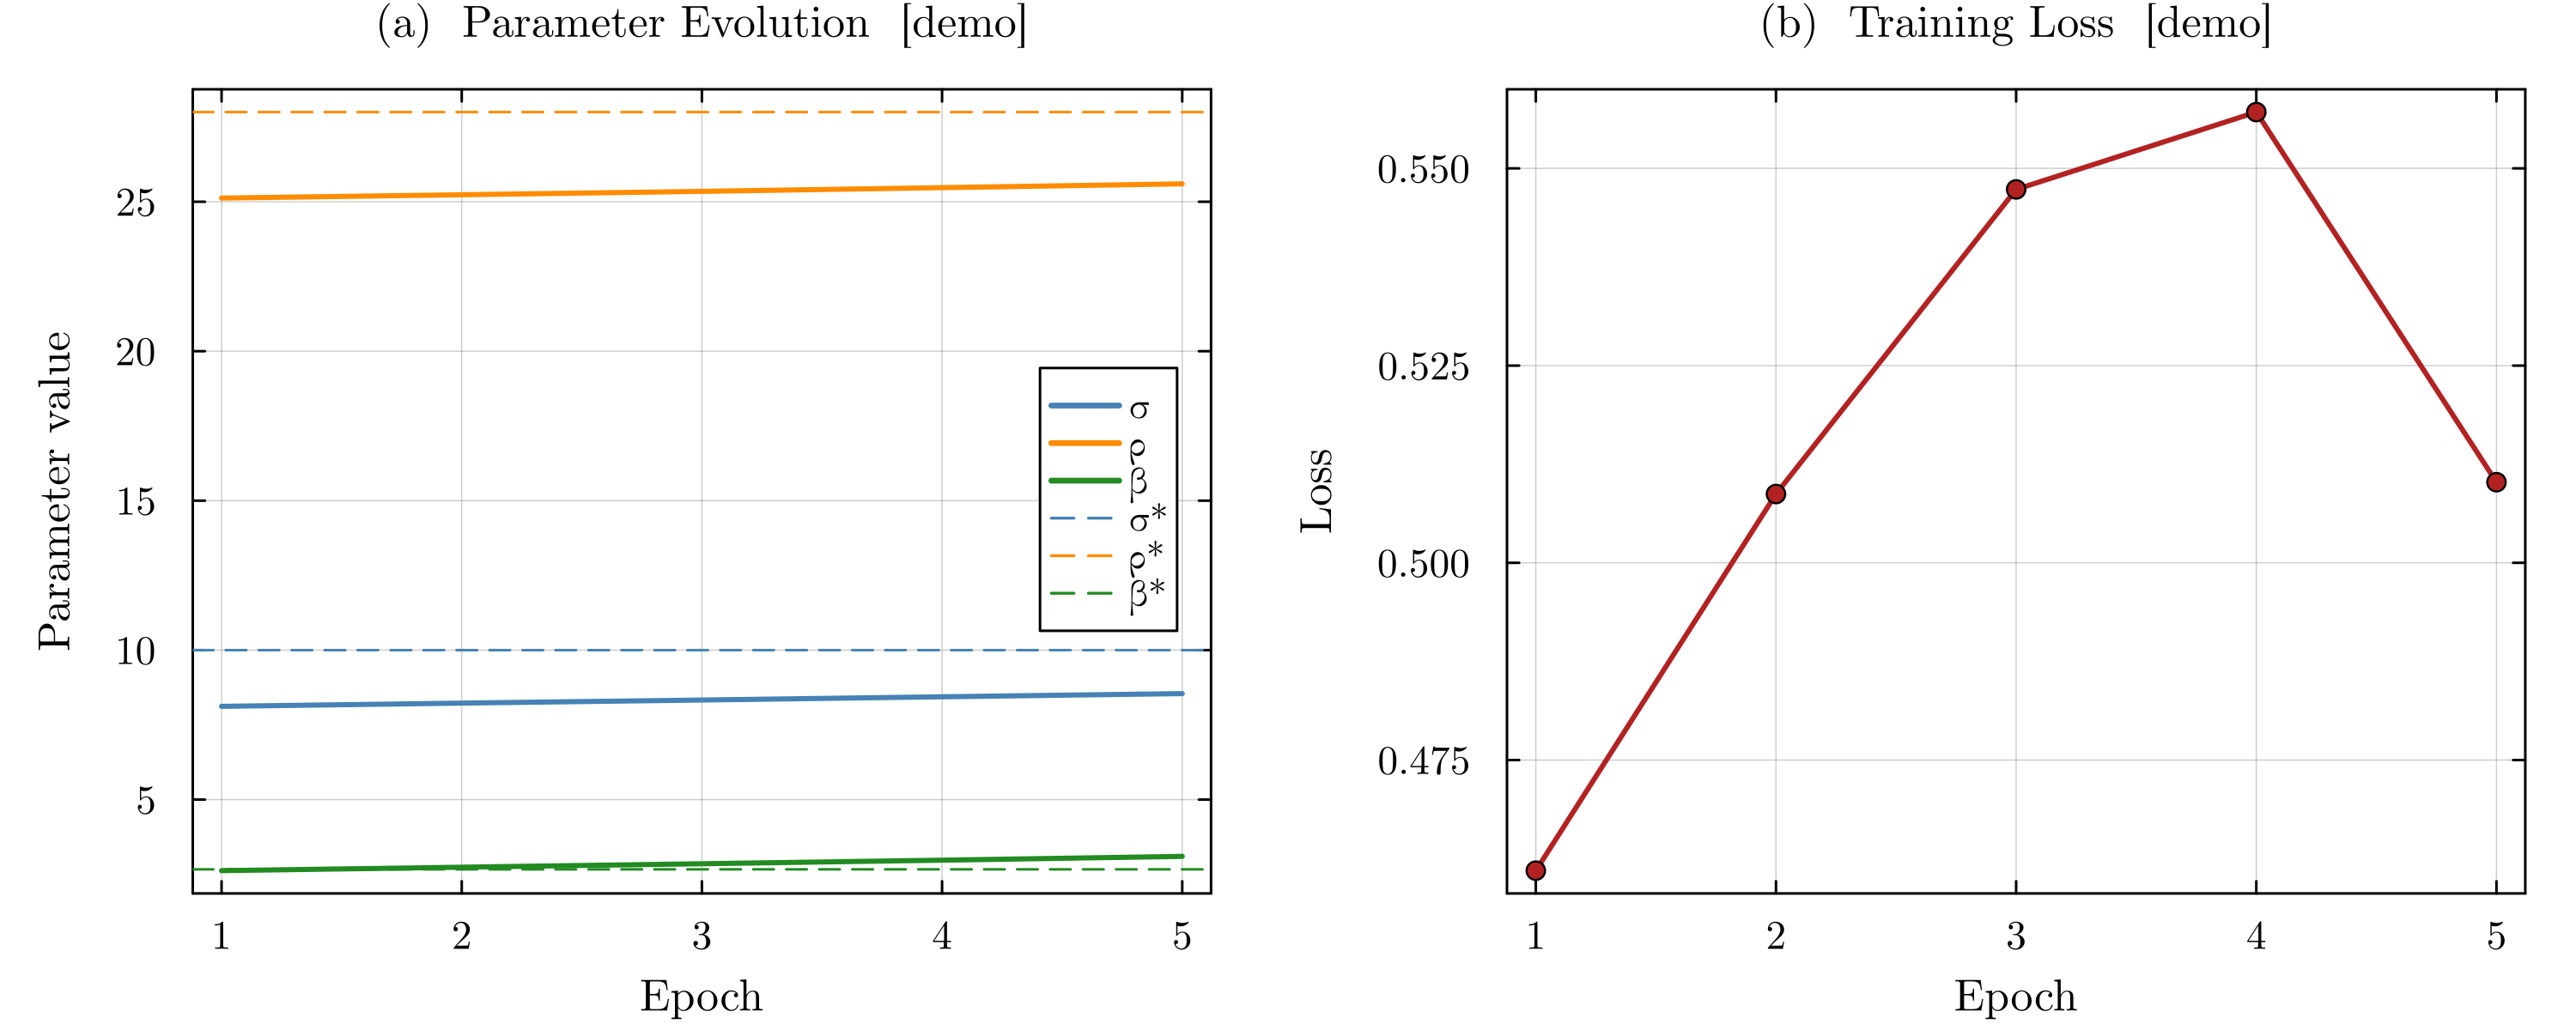

Saved → p34_training_demo.png


In [56]:
# ── Publication styling (shared variables from p1 cell) ───────────────────────
lw_s  = 2.0
cσ_s, cρ_s, cβ_s = :steelblue, :darkorange, :forestgreen

kw_s = (;
    titlefontsize  = fs_pub,
    guidefontsize  = fs_pub,
    tickfontsize   = fs_pub - 1,
    legendfontsize = fs_pub - 2,
    framestyle     = :box,
    left_margin    = 7Plots.mm,
    bottom_margin  = 5Plots.mm,
    top_margin     = 4Plots.mm,
    right_margin   = 3Plots.mm,
)

epo    = 1:length(param_history)
σ_vals = [p.σ for p in param_history]
ρ_vals = [p.ρ for p in param_history]
β_vals = [p.β for p in param_history]

# ── p3: parameter evolution ───────────────────────────────────────────────────
p3 = Plots.plot(epo, σ_vals; color=cσ_s, lw=lw_s, label="σ",
    xlabel = "Epoch", ylabel = "Parameter value",
    title  = "(a)  Parameter Evolution  [demo]",
    kw_s...
)
Plots.plot!(p3, epo, ρ_vals; color=cρ_s, lw=lw_s, label="ρ")
Plots.plot!(p3, epo, β_vals; color=cβ_s, lw=lw_s, label="β")
Plots.hline!(p3, [true_params.σ]; color=cσ_s, lw=1.0, ls=:dash, label="σ*")
Plots.hline!(p3, [true_params.ρ]; color=cρ_s, lw=1.0, ls=:dash, label="ρ*")
Plots.hline!(p3, [true_params.β]; color=cβ_s, lw=1.0, ls=:dash, label="β*")
Plots.plot!(p3; legend = :right)

# ── p4: training loss ─────────────────────────────────────────────────────────
p4 = Plots.plot(epo, loss_history;
    color      = :firebrick,
    lw         = lw_s,
    marker     = :circle,
    markersize = 4,
    xlabel     = "Epoch",
    ylabel     = "Loss",
    title      = "(b)  Training Loss  [demo]",
    legend     = false,
    kw_s...
)

# ── Combined figure ────────────────────────────────────────────────────────────
fig_p34 = Plots.plot(p3, p4; layout = (1, 2), size = (1000, 400), dpi = 300)

display(fig_p34)
Plots.savefig(fig_p34, joinpath(IMG_DIR, "p34_training_demo.png"))
Plots.savefig(p3,      joinpath(IMG_DIR, "p3_parameter_evolution.png"))
Plots.savefig(p4,      joinpath(IMG_DIR, "p4_training_loss.png"))
Plots.default(fontfamily = "sans-serif")
println("Saved → p34_training_demo.png")

## Step 10: Real Training Run + Publication Figure

We now run `modular_train!` for real — using Enzyme autodiff and the full mini-batch SGD pipeline — and produce a publication-quality convergence figure.

In [57]:
# ── Real training run ────────────────────────────────────────────────────────
Random.seed!(42)

init_params_pub = L63Parameters(σ=6.0, ρ=20.0, β=1,
                                x_s=0.0, y_s=0.0, z_s=0.0, θ=1.0)

result = modular_train!(
    init_params_pub, target_solution;
    optimizer_config  = adam_config(learning_rate=0.01),
    window_size       = 100,
    stride            = 50,
    batch_size        = 8,
    epochs            = 60,
    update_σ          = true,
    update_ρ          = true,
    update_β          = true,
    verbose           = true,
    eval_every        = 5,
)

println("\nBest parameters found:")
println("  σ = $(round(result.best_params.σ, digits=4))  (true: $(true_params.σ))")
println("  ρ = $(round(result.best_params.ρ, digits=4))  (true: $(true_params.ρ))")
println("  β = $(round(result.best_params.β, digits=4))  (true: $(round(true_params.β, digits=4)))")

   Optimizer: Adam
   Data: 159 train windows, 40 val windows
   Window size: 100, stride: 50
   Updating: σ, ρ, β

Epoch │   Train    │    Val     │ Parameters
──────┼────────────┼────────────┼────────────────────────────
    1 │   6.631127 │     —      │ σ=6.190,ρ=20.195,β=1.169
    2 │   6.484919 │     —      │ σ=6.350,ρ=20.395,β=1.317
    3 │   6.348531 │     —      │ σ=6.510,ρ=20.604,β=1.456
    4 │   6.213462 │     —      │ σ=6.680,ρ=20.820,β=1.574
    5 │   6.077785 │   6.591246 │ σ=6.835,ρ=21.035,β=1.703
    6 │   5.933788 │   6.591246 │ σ=6.975,ρ=21.264,β=1.809
    7 │   5.785338 │   6.591246 │ σ=7.136,ρ=21.496,β=1.918
    8 │   5.626530 │   6.591246 │ σ=7.285,ρ=21.736,β=2.023
    9 │   5.456116 │   6.591246 │ σ=7.438,ρ=21.976,β=2.137
   10 │   5.275564 │   5.717358 │ σ=7.597,ρ=22.221,β=2.268
   11 │   5.075749 │   5.717358 │ σ=7.752,ρ=22.469,β=2.387
   12 │   4.868661 │   5.717358 │ σ=7.912,ρ=22.727,β=2.528
   13 │   4.642324 │   5.717358 │ σ=8.070,ρ=22.986,β=2.673
   14 │   

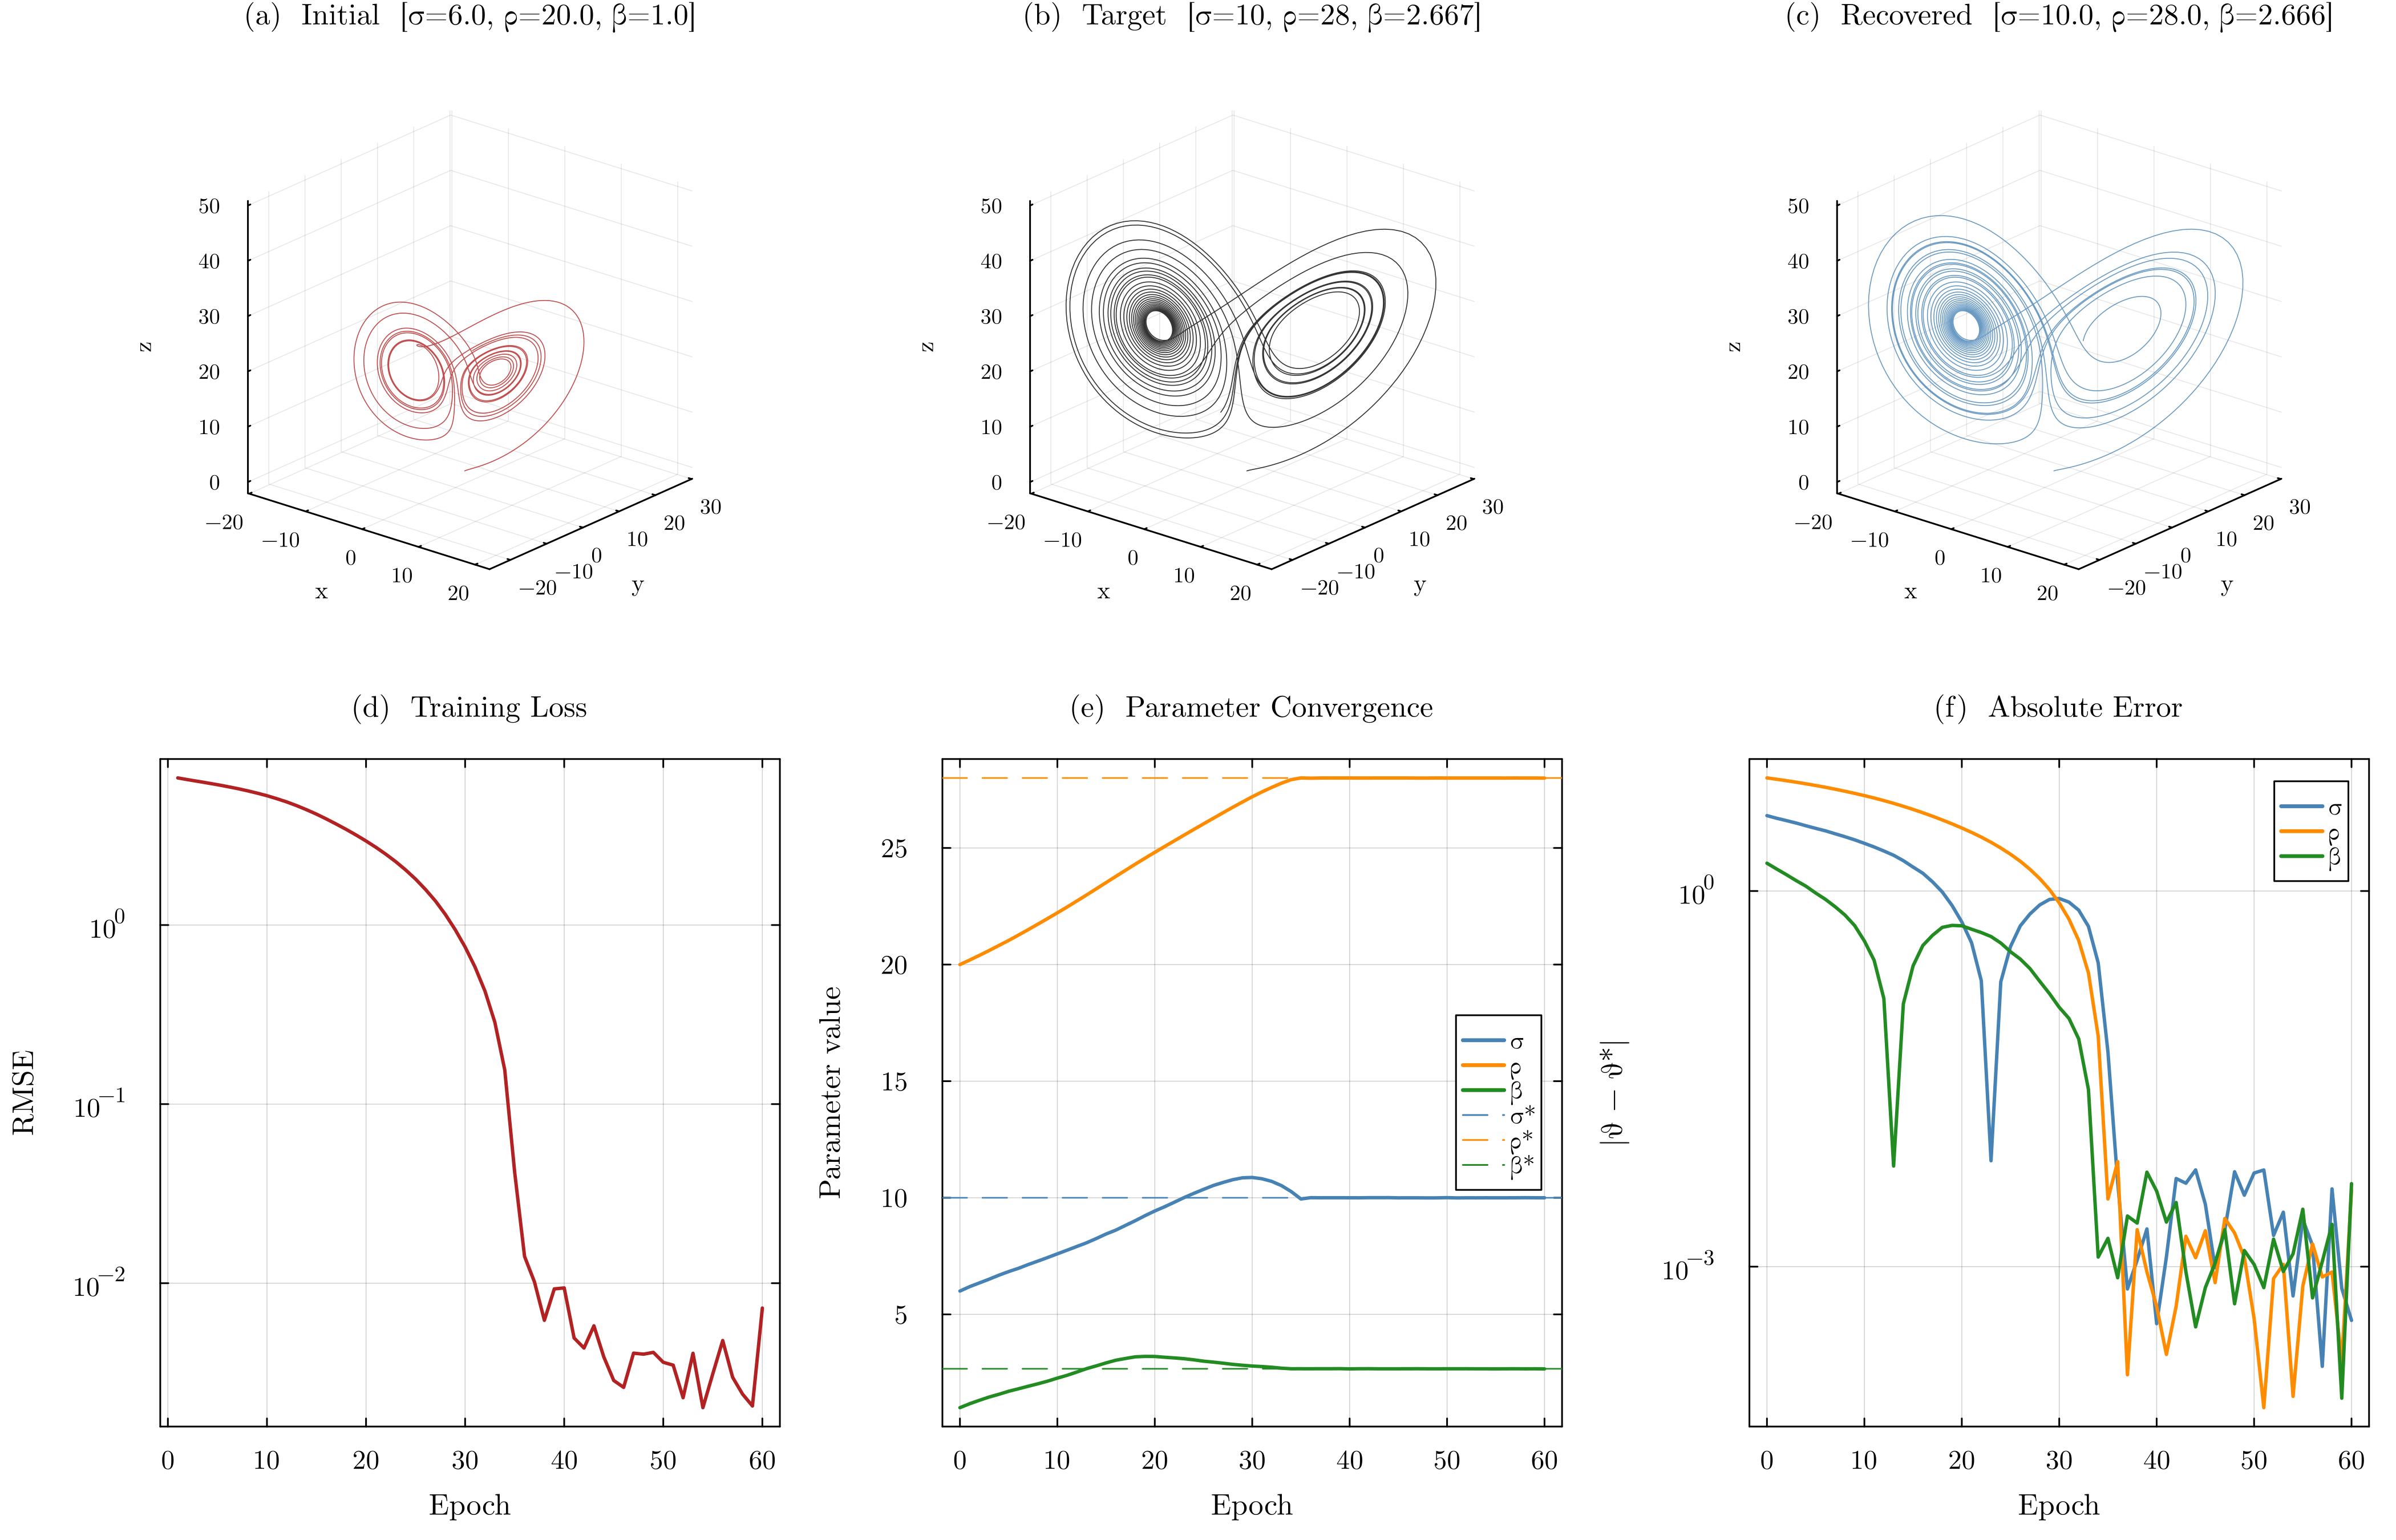

Saved → /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_weather/walkthrough/img/publication_training_convergence.png


In [58]:
# ── Publication-quality 6-panel figure ───────────────────────────────────────
Plots.gr()
Plots.default(fontfamily = "Computer Modern")

# ── Generate attractor trajectories for visual comparison ─────────────────────
T_vis, dt_vis = 25.0, 0.005
traj_init   = integrate(init_params_pub,    [1.0, 1.0, 1.0], (0.0, T_vis), dt_vis)
traj_target = integrate(true_params,        [1.0, 1.0, 1.0], (0.0, T_vis), dt_vis)
traj_final  = integrate(result.best_params, [1.0, 1.0, 1.0], (0.0, T_vis), dt_vis)

# Shared axis limits derived from the target attractor
pad = 3.0
xl = (minimum(traj_target.u[:,1]) - pad, maximum(traj_target.u[:,1]) + pad)
yl = (minimum(traj_target.u[:,2]) - pad, maximum(traj_target.u[:,2]) + pad)
zl = (minimum(traj_target.u[:,3]) - pad, maximum(traj_target.u[:,3]) + pad)

# ── Shared keyword bundles ─────────────────────────────────────────────────────
fs   = 11
lw3  = 0.55
lw2  = 2.0
cam  = (40, 22)
cσ, cρ, cβ = :steelblue, :darkorange, :forestgreen

kw3d = (;
    seriestype    = :path3d,
    linewidth     = lw3,
    alpha         = 0.80,
    legend        = false,
    xlims = xl, ylims = yl, zlims = zl,
    xlabel = "x",  ylabel = "y",  zlabel = "z",
    camera        = cam,
    titlefontsize = fs,
    guidefontsize = fs - 2,
    tickfontsize  = fs - 3,
    top_margin    = 4Plots.mm,
    bottom_margin = 1Plots.mm,
    left_margin   = 0Plots.mm,
    right_margin  = 0Plots.mm,
)

kw2d = (;
    titlefontsize  = fs,
    guidefontsize  = fs,
    tickfontsize   = fs - 1,
    legendfontsize = fs - 2,
    frame          = :box,
    left_margin    = 6Plots.mm,
    bottom_margin  = 5Plots.mm,
    top_margin     = 4Plots.mm,
    right_margin   = 2Plots.mm,
)

# ── Row 1: Lorenz attractors ───────────────────────────────────────────────────
σ0, ρ0, β0 = init_params_pub.σ, init_params_pub.ρ, round(init_params_pub.β, digits=3)
σf = round(result.best_params.σ, digits=2)
ρf = round(result.best_params.ρ, digits=2)
βf = round(result.best_params.β, digits=3)

p_init = Plots.plot(
    traj_init.u[:,1], traj_init.u[:,2], traj_init.u[:,3];
    title      = "(a)  Initial  [σ=$(σ0), ρ=$(ρ0), β=$(β0)]",
    linecolor  = :firebrick,
    kw3d...
)

p_target = Plots.plot(
    traj_target.u[:,1], traj_target.u[:,2], traj_target.u[:,3];
    title     = "(b)  Target  [σ=10, ρ=28, β=2.667]",
    linecolor = :black,
    kw3d...
)

p_final = Plots.plot(
    traj_final.u[:,1], traj_final.u[:,2], traj_final.u[:,3];
    title     = "(c)  Recovered  [σ=$(σf), ρ=$(ρf), β=$(βf)]",
    linecolor = :steelblue,
    kw3d...
)

# ── Row 2: Convergence diagnostics ────────────────────────────────────────────
ph     = result.param_history
tl     = result.train_loss
ep     = 0:length(tl)
ep_l   = 1:length(tl)

σ_hist = [p.σ for p in ph]
ρ_hist = [p.ρ for p in ph]
β_hist = [p.β for p in ph]
err_σ  = abs.(σ_hist .- true_params.σ)
err_ρ  = abs.(ρ_hist .- true_params.ρ)
err_β  = abs.(β_hist .- true_params.β)

p_loss = Plots.plot(ep_l, tl;
    yscale  = :log10,
    color   = :firebrick,
    lw      = lw2,
    xlabel  = "Epoch",
    ylabel  = "RMSE",
    title   = "(d)  Training Loss",
    legend  = false,
    kw2d...
)

p_params = Plots.plot(ep, σ_hist; color=cσ, lw=lw2, label="σ",
    xlabel = "Epoch",
    ylabel = "Parameter value",
    title  = "(e)  Parameter Convergence",
    kw2d...
)
Plots.plot!(p_params, ep, ρ_hist; color=cρ, lw=lw2, label="ρ")
Plots.plot!(p_params, ep, β_hist; color=cβ, lw=lw2, label="β")
Plots.hline!(p_params, [true_params.σ]; color=cσ, lw=0.9, ls=:dash, label="σ*")
Plots.hline!(p_params, [true_params.ρ]; color=cρ, lw=0.9, ls=:dash, label="ρ*")
Plots.hline!(p_params, [true_params.β]; color=cβ, lw=0.9, ls=:dash, label="β*")
Plots.plot!(p_params; legend=:right)

p_err = Plots.plot(ep, err_σ; color=cσ, lw=lw2, label="σ",
    yscale  = :log10,
    xlabel  = "Epoch",
    ylabel  = "|θ − θ*|",
    title   = "(f)  Absolute Error",
    kw2d...
)
Plots.plot!(p_err, ep, err_ρ; color=cρ, lw=lw2, label="ρ")
Plots.plot!(p_err, ep, err_β; color=cβ, lw=lw2, label="β")
Plots.plot!(p_err; legend=:topright)

# ── Combine: {h} on the first cell of each row sets that row's height ──────────
l = @layout [
    a{0.45h} b c
    d        e f
]

fig_pub = Plots.plot(
    p_init, p_target, p_final,
    p_loss, p_params, p_err;
    layout = l,
    size   = (1400, 900),
    dpi    = 300,
)

display(fig_pub)
Plots.savefig(fig_pub, joinpath(IMG_DIR, "publication_training_convergence.png"))
println("Saved → ", joinpath(IMG_DIR, "publication_training_convergence.png"))

Plots.default(fontfamily = "sans-serif")